# Concrete Compressive Strength Prediction
### An AI + Civil Engineering project

**Goal:** predict the compressive strength of concrete (in MPa) from its mix design — the amounts of cement, water, aggregates, etc. — and its curing age.

This is a real, well-known dataset (I-Cheng Yeh, 1998, donated to the UCI Machine Learning Repository) used in structural/materials engineering research. It's a good project for combining civil engineering knowledge with an intro AI/ML course because you already understand *why* the inputs matter — you're not just fitting numbers blindly.

**Before running this notebook**, download the dataset (1 file, ~1030 rows):
- Kaggle (easiest, ready-made CSV, free account needed): https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set
- Or the original UCI page (downloads as .xls): https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength

Save the file in the same folder as this notebook (or upload it to Colab) and update the filename in the cell below if needed.

**The 8 inputs and 1 output, in this fixed order:**
1. Cement (kg/m³)
2. Blast Furnace Slag (kg/m³)
3. Fly Ash (kg/m³)
4. Water (kg/m³)
5. Superplasticizer (kg/m³)
6. Coarse Aggregate (kg/m³)
7. Fine Aggregate (kg/m³)
8. Age (days)
9. **Compressive Strength (MPa)** — this is what we're predicting


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.width', 120)


## Step 1 — Load the data

Different mirrors of this dataset (Kaggle vs UCI vs GitHub copies) sometimes use slightly different column headers.
Since the *order* of the 9 columns is always the same, we assign clean names by position instead of trusting whatever headers came in the file. This makes the notebook work no matter which source you downloaded from.

In [14]:
FILENAME = "concrete_data.csv"  # <-- change this if your downloaded file has a different name

df = pd.read_csv(FILENAME)

df.columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_aggregate", "fine_aggregate", "age", "strength"
]

print(df.shape)
df.head()


(1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## Step 2 — Explore the data

Basic sanity checks first: data types, missing values, and summary statistics. Always look at your data before modeling it — it's easy to miss a unit mismatch or a bad row otherwise.

In [15]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum())
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_aggregate  1030 non-null   float64
 6   fine_aggregate    1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

Missing values per column:
cement              0
slag                0
fly_ash             0
water               0
superplasticizer    0
coarse_aggregate    0
fine_aggregate      0
age                 0
strength            0
dtype: int64


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


strength            1.000000
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
fly_ash            -0.105755
coarse_aggregate   -0.164935
fine_aggregate     -0.167241
water              -0.289633
Name: strength, dtype: float64


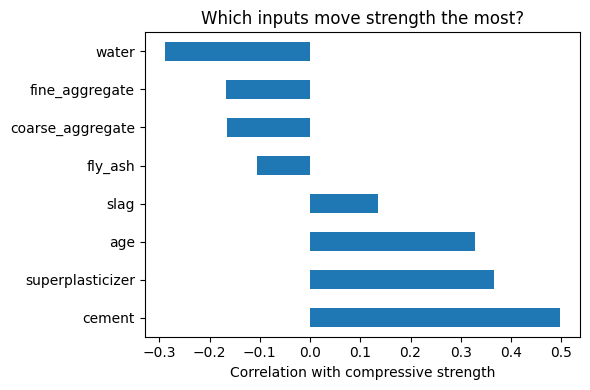

In [16]:
# How strongly is each ingredient correlated with strength?
corr = df.corr()["strength"].sort_values(ascending=False)
print(corr)

fig, ax = plt.subplots(figsize=(6, 4))
corr.drop("strength").plot(kind="barh", ax=ax)
ax.set_xlabel("Correlation with compressive strength")
ax.set_title("Which inputs move strength the most?")
plt.tight_layout()
plt.show()


**Engineering read on this before you even model it:** cement and age usually show the strongest positive correlation with strength (more cement, more time to cure -> stronger concrete), while water tends to correlate negatively — a higher water-to-cement ratio is classically known to weaken concrete. Superplasticizer often helps because it lets you use less water while keeping the mix workable. Keep this in mind as a sanity check once the model gives you its own answer in Step 5 — if the model completely disagrees with known concrete theory, that's a sign something's wrong with the data or the model, not that 70 years of materials science is wrong.

## Step 3 — Split into training and test sets

We hold out 20% of the data that the model never sees during training, so we can honestly check how well it generalizes to new mixes.

In [6]:
X = df.drop(columns=["strength"])
y = df["strength"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples")


Training on 824 samples, testing on 206 samples


## Step 4 — Baseline model: Linear Regression

Always start with the simplest model. It tells you the "floor" — if a much fancier model can't beat this by much, the fancier model isn't earning its complexity.

In [7]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

lin_mae = mean_absolute_error(y_test, y_pred_lin)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
lin_r2 = r2_score(y_test, y_pred_lin)

print(f"Linear Regression  ->  MAE: {lin_mae:.2f} MPa   RMSE: {lin_rmse:.2f} MPa   R2: {lin_r2:.3f}")


Linear Regression  ->  MAE: 7.75 MPa   RMSE: 9.80 MPa   R2: 0.628


## Step 5 — Better model: Random Forest

Concrete strength is a genuinely nonlinear function of its ingredients (this is stated directly in the original research this dataset comes from) — cement and water don't just add up, they interact. A Random Forest can capture that nonlinearity where plain linear regression can't.

In [8]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest      ->  MAE: {rf_mae:.2f} MPa   RMSE: {rf_rmse:.2f} MPa   R2: {rf_r2:.3f}")

print("\nImprovement over the linear baseline:")
print(f"  R2:  {lin_r2:.3f} -> {rf_r2:.3f}")
print(f"  MAE: {lin_mae:.2f} MPa -> {rf_mae:.2f} MPa")


Random Forest      ->  MAE: 3.79 MPa   RMSE: 5.54 MPa   R2: 0.881

Improvement over the linear baseline:
  R2:  0.628 -> 0.881
  MAE: 7.75 MPa -> 3.79 MPa


## Step 6 — Which ingredient matters most, according to the model?

This is the part that makes the project actually *engineering* work, not just a coding exercise: turning model output back into a statement about concrete.

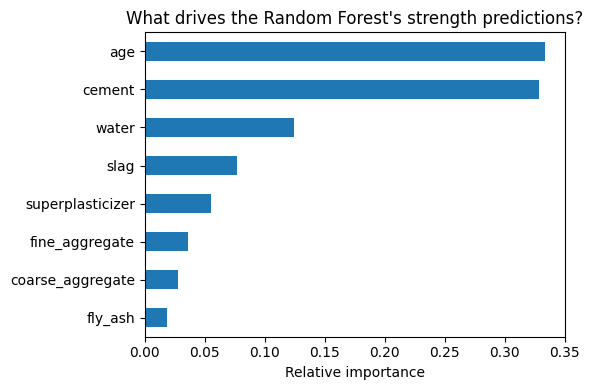

age                 0.333434
cement              0.328734
water               0.124154
slag                0.076811
superplasticizer    0.055045
fine_aggregate      0.035848
coarse_aggregate    0.027341
fly_ash             0.018632
dtype: float64


In [9]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Relative importance")
ax.set_title("What drives the Random Forest's strength predictions?")
plt.tight_layout()
plt.show()

print(importances)


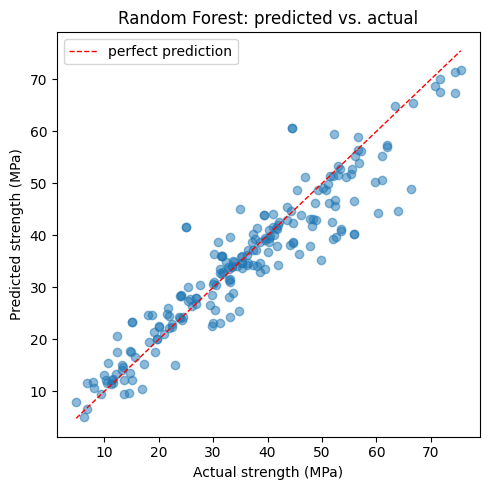

In [10]:
# Predicted vs actual strength -- a quick visual gut-check on the model
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.5)
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label="perfect prediction")
ax.set_xlabel("Actual strength (MPa)")
ax.set_ylabel("Predicted strength (MPa)")
ax.set_title("Random Forest: predicted vs. actual")
ax.legend()
plt.tight_layout()
plt.show()


## Step 7 — Write-up (fill this in yourself once you've run the notebook on the real data)

A few sentences here turns this from "a script that ran" into an actual engineering finding. Answer, in your own words, once you see your real numbers:

- Which 2–3 inputs turned out to matter most for predicted strength, and does that match what you'd expect from concrete theory (cement content, water-cement ratio, curing age)?Age and cement were the two most important predictors (0.33 each, together accounting for roughly two-thirds of the model's importance scores), both correlating positively with strength. Water was third in importance (0.12) but correlates negatively — consistent with the classic water-cement ratio effect in concrete design.
- How much better was the Random Forest than plain Linear Regression (R², MAE)? What does that gap tell you about how nonlinear this relationship really is?Random Forest outperformed Linear Regression on both metrics: R² improved from 0.628 to 0.881, and average prediction error (MAE) dropped from 7.75 MPa to 3.79 MPa. The large gap between the two models suggests concrete's ingredients don't act independently — their effects on strength depend on each other, which is exactly the kind of relationship a linear model can't capture but a Random Forest can.
- If you were mixing concrete for a real project, what's one practical takeaway from this model — e.g. which variable would you prioritize controlling tightly?Cement and water are the two inputs I can actually control when designing a mix, and cement is the more influential of the two — so I'd prioritize getting the cement content (and the water-cement ratio specifically) right, since age will pass on its own regardless of what I do.

*(This section is intentionally left for you to complete after running your own data — it's the part that shows understanding, not just execution.)*


## Optional next steps, if you want to push this further
- Try `GradientBoostingRegressor` or `xgboost` and compare against the Random Forest.
- Tune `n_estimators` / `max_depth` with `GridSearchCV` and see if it meaningfully improves R².
- Engineer a new feature: water-to-cement ratio (`water / cement`) is a classic civil engineering metric — see if adding it as an explicit column helps the linear model in particular.
- Push this notebook + a short README to GitHub, and post a summary on LinkedIn once your write-up is filled in.
